# 04 — Stage 1 Data: Training Universe and Label Distributions

Four Dutch cities (Amsterdam, Rotterdam, Utrecht, Delft). Training universe = SVI manifest ∩ Stage-1 GT.
This notebook documents per-city train/holdout sizes and the two label distributions Stage 1 actually predicts: **building_type** and **tabula_period**.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd()))
from _stage1_plot import (
    REPO, FIG_DIR, TABLE_DIR,
    setup_mpl, save_fig, save_table,
    TYPE_LABELS, CITY_LABELS, PERIOD_LABELS,
    TYPE_PALETTE, CITY_PALETTE,
)

setup_mpl()

manifest = pd.read_parquet(REPO / 'data/processed/svi_manifest.parquet')
gt       = pd.read_parquet(REPO / 'data/processed/stage1_gt.parquet')
holdout  = pd.read_parquet(REPO / 'data/processed/holdout_test_pand_ids.parquet')
for df in (manifest, gt, holdout):
    df['pand_id'] = df['pand_id'].astype(str)

universe = sorted(set(manifest['pand_id']) & set(gt['pand_id']))
print(f'manifest images       = {len(manifest):>7,}')
print(f'manifest buildings    = {manifest["pand_id"].nunique():>7,}')
print(f'GT buildings (4 city) = {gt["pand_id"].nunique():>7,}')
print(f'training universe     = {len(universe):>7,}  (manifest ∩ GT)')
print(f'holdout buildings     = {len(holdout):>7,}')

manifest images       =  47,238
manifest buildings    =  10,104
GT buildings (4 city) = 124,784
training universe     =  10,086  (manifest ∩ GT)
holdout buildings     =   2,018


## 1. Training universe

In [2]:
uni_set = set(universe)
ho_set  = set(holdout['pand_id'])
manifest_uni = manifest[manifest['pand_id'].isin(uni_set)].copy()
manifest_uni['split'] = manifest_uni['pand_id'].map(
    lambda pid: 'holdout' if pid in ho_set else 'train'
)

agg = (
    manifest_uni.groupby(['city', 'split'])
    .agg(buildings=('pand_id', 'nunique'),
         images=('pand_id', 'size'))
    .reset_index()
    .pivot(index='city', columns='split', values=['buildings', 'images'])
)
agg.columns = [f'{a}_{b}' for a, b in agg.columns]
agg = agg.reindex(CITY_LABELS).reset_index()
agg = agg[['city', 'buildings_train', 'images_train', 'buildings_holdout', 'images_holdout']]
agg = agg.rename(columns={
    'buildings_train': 'train_buildings',
    'images_train':    'train_images',
    'buildings_holdout': 'holdout_buildings',
    'images_holdout':    'holdout_images',
})
total = agg.drop(columns=['city']).sum().to_dict()
total['city'] = 'TOTAL'
agg_with_total = pd.concat([agg, pd.DataFrame([total])], ignore_index=True)
for c in ['train_buildings', 'train_images', 'holdout_buildings', 'holdout_images']:
    agg_with_total[c] = agg_with_total[c].astype(int)
save_table(agg_with_total, 'T1_per_city_train_holdout')
agg_with_total

[tbl] reports\tables\stage1\T1_per_city_train_holdout.csv  +  T1_per_city_train_holdout.md


,city,train_buildings,train_images,holdout_buildings,holdout_images
0,amsterdam,6416,29309,1595,7215
1,rotterdam,1129,5864,286,1460
2,utrecht,384,1778,103,454
3,delft,139,871,34,199
4,TOTAL,8068,37822,2018,9328


## 2. Label distributions (training universe)

Stage 1 trains three heads against `building_type`, `bouwjaar` (year), and `num_floors` (see `src/stage1/{dataset,models}.py`). `tabula_period` is a bucket of `bouwjaar` used only as a stratification key, and `Energieklasse` is reserved as the Stage 2/3 target — neither is a Stage 1 prediction. Top row below shows trained targets; bottom row shows the two non-target labels carried for stratification and downstream use.

[fig] reports\figures\stage1\data\F1_label_distributions.png  +  F1_label_distributions.pdf


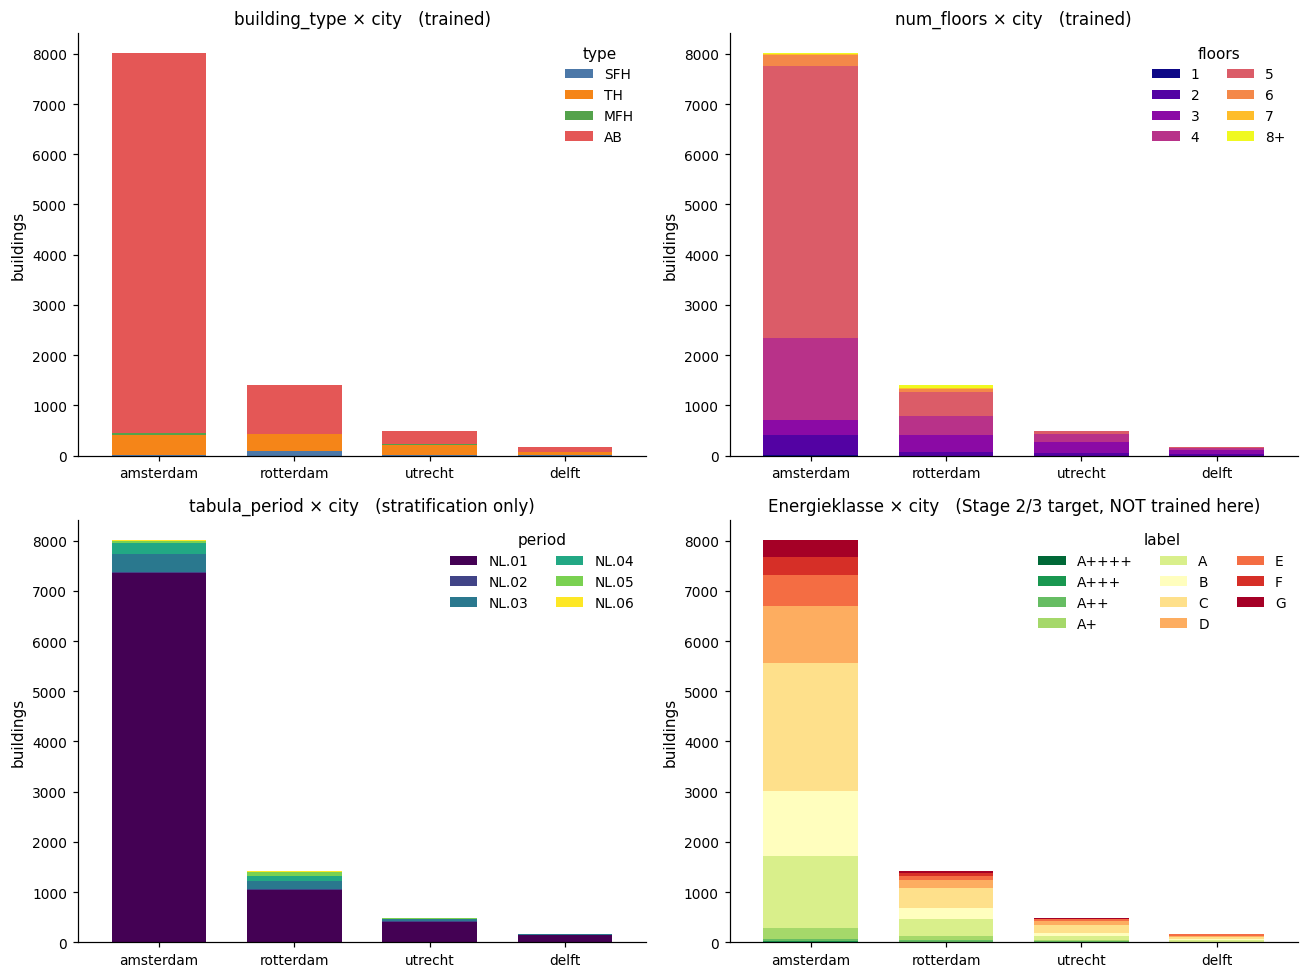

In [3]:
import matplotlib.pyplot as plt

uni_gt = gt[gt['pand_id'].isin(uni_set)].copy()

FLOOR_BUCKETS = ['1', '2', '3', '4', '5', '6', '7', '8+']
def _floor_bucket(n):
    n = int(n)
    return str(n) if n <= 7 else '8+'
uni_gt['floor_bucket'] = uni_gt['num_floors'].map(_floor_bucket)

ENERGY_LABELS = ['A++++', 'A+++', 'A++', 'A+', 'A', 'B', 'C', 'D', 'E', 'F', 'G']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (0,0) building_type × city  — TRAINED TARGET
type_city = (
    uni_gt.groupby(['city', 'building_type']).size()
    .unstack(fill_value=0)
    .reindex(index=CITY_LABELS)
    .reindex(columns=TYPE_LABELS, fill_value=0)
)
type_city.plot(kind='bar', stacked=True, ax=axes[0, 0],
               color=[TYPE_PALETTE[t] for t in TYPE_LABELS], width=0.7)
axes[0, 0].set_title('building_type × city   (trained)')
axes[0, 0].set_xlabel(''); axes[0, 0].set_ylabel('buildings')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend(title='type', loc='upper right', frameon=False)

# (0,1) num_floors × city  — TRAINED TARGET
floor_city = (
    uni_gt.groupby(['city', 'floor_bucket']).size()
    .unstack(fill_value=0)
    .reindex(index=CITY_LABELS)
    .reindex(columns=FLOOR_BUCKETS, fill_value=0)
)
floor_city.plot(kind='bar', stacked=True, ax=axes[0, 1],
                colormap='plasma', width=0.7)
axes[0, 1].set_title('num_floors × city   (trained)')
axes[0, 1].set_xlabel(''); axes[0, 1].set_ylabel('buildings')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='floors', loc='upper right', frameon=False, ncol=2)

# (1,0) tabula_period × city  — derived from bouwjaar, stratification only
period_city = (
    uni_gt.groupby(['city', 'tabula_period']).size()
    .unstack(fill_value=0)
    .reindex(index=CITY_LABELS)
    .reindex(columns=PERIOD_LABELS, fill_value=0)
)
period_city.plot(kind='bar', stacked=True, ax=axes[1, 0],
                 colormap='viridis', width=0.7)
axes[1, 0].set_title('tabula_period × city   (stratification only)')
axes[1, 0].set_xlabel(''); axes[1, 0].set_ylabel('buildings')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(title='period', loc='upper right', frameon=False, ncol=2)

# (1,1) Energieklasse × city  — Stage 2/3 target, NOT trained at Stage 1
energy_city = (
    uni_gt.groupby(['city', 'Energieklasse']).size()
    .unstack(fill_value=0)
    .reindex(index=CITY_LABELS)
    .reindex(columns=ENERGY_LABELS, fill_value=0)
)
energy_city.plot(kind='bar', stacked=True, ax=axes[1, 1],
                 colormap='RdYlGn_r', width=0.7)
axes[1, 1].set_title('Energieklasse × city   (Stage 2/3 target, NOT trained here)')
axes[1, 1].set_xlabel(''); axes[1, 1].set_ylabel('buildings')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(title='label', loc='upper right', frameon=False, ncol=3)

fig.tight_layout()
save_fig(fig, 'F1_label_distributions', 'data')
plt.show()